# KPI 2 - Relative Racecraft Performance - Feature Engineering 

This notebook focuses on feature engineering to respond to 'Strategic Question 2' from the project's research stage. 

**Question 2:** 
>*In 2018 and 2019 qualifying sessions, where did Williams lose the most time relative to the fastest midfield performances, and were these performance gaps more pronounced in technical versus power-focused sectors?*

**KPI 2:**
>*Qualifying Sector Performance Delta: Time deficit of Williams' fastest qualifying performance to the fastest midfield performance per sector, grouped by sector type.*

**Hypothesis 2:**
>*Williams' fastest qualifying sector times showed significantly larger deficits to midfield rivals in technical sectors compared to power sectors, indicating fundamental aerodynamic and chassis setup limitations rather than engine-related deficiencies.*

Note: unlike the feature engineering stages for other strategic questions, Question 2 is done through the Fast-F1 API, which only has accurate lap data from 2018 onwards. 

Hence, our time period is limited from 2015-2019 to 2018 and 2019 for this question only.

**Steps required:**
1. Manually label each circuit and sector as one of 'power', 'technical', or 'balanced' for sector aggregatin and comparison purposes.

2. Load all relevant qualifying sessions, process data and store it as a DataFrame and CSV, "all_laps_df_cleaned.csv" for further operations.

3. Load processed data "all_laps_df_cleaned.csv" a as DataFrame. Ensure sector and lap time columns are clean and parseable (e.g. convert str to time data)

4. Filter by teams, valid laps, and each driver's fastest lap. Remember: filter accurate, fastest laps only - avoids external noise. 

5. Feature Engineering: 
	
    5.1. Generate comparison baseline - for each session, find the best/lowest sector times.
		Forms session-specific baseline for each sector.
	
    5.2 Calculate Williams' delta to the fastest midfield team, if Williams' isn't the fastest.
		E.g. delta = Williams sector time - fastest midfield sector time. Repeat for S1, S2, S3. 
			Store as `s1_delta`, `s2_delta`, `s3_delta` in seconds.
	
    5.3 Attach circuit & sector type - map `circuit_type` and `sector_type` column and label each circuit/sector as power, technical or balanced

6. Aggregation & Grouping: 
	
    6.1 Melt data to long or MultiIndex format - each row should represent one sector per lap e.g. index1 = lap, index2 = sector (3 index2s for 1 index1)
		Could store as 'Year', 'Race', 'Driver', 'Sector', 'Sector_Delta', 'Sector_Type'
		Helpful for `groupby()`, visualisation, hypothesis tests.
	
    6.2. Aggregate by type - calculate average (mean/median) and spread (std/MAD/IQR) with sector delta for Williams through circuit_type/sector_type.
	
    6.3. Aggregate for other midfield rivals for broader comparison/sanity checks.

7. Identify and treat any outliers, if present. Label carefully if needed, or consider removing them.

8. Prepare for visualisation and hypothesis testing. 
	
    8.1 Export to CSV if needed. e.g each row: `Year`, `Race`, `Driver`, `Sector`, `Sector_Delta`, `Sector_Type`, `Circuit_Type`.
	
    8.2 For hypothesis testing: group sector deltas by sector type or use t-tests for statistical significance.
	
    8.3 For visualisation: use boxplots, heatmaps, or barplots.

## Step 1: Label circuits and sectors

### Why label sectors and circuits?
To truly understand a car’s strengths and weaknesses in Formula 1, it’s not enough to compare overall lap times—you need to break performance down into where and how time is gained or lost on the circuit. 

F1 tracks are diverse, with each made up of multiple sectors featuring different technical demands. 

Labeling each circuit and its sectors by type allows targeted benchmarking and diagnosis.

### Key Rationale
- Circuit and sector labels (e.g. technical, power, balanced) encode the engineering challenge presented by each part of the track. Some reward straight-line speed; others expose weaknesses in cornering, braking, or traction.

- Segmenting performance by type makes it possible to:
	- Reveal if a team’s deficit is due to straight-line speed, downforce, or mechanical grip.
	- Aggregate and compare performance over structurally similar track features (e.g. all technical sectors).
	- Produce actionable findings for car design and setup strategy.

### What Do the Labels Mean?
- **Power**: Sectors or circuits featuring long straights and high-speed corners, where engine power is critical. Teams are rewarded for high top speeds and strong power units. 
    - **Circuit Example**: Italian GP (Monza) - the 'Temple of Speed', featuring >75% full throttle and long straights. 
    - **Sector Example**: Sector 1 of the Belgian GP (Spa) - dominated by the run from La Source through the upwards Eau Rouge and the Kemmel straight.

- **Technical**: Sections with numerous low-speed corners, short straights, and complex directional changes. Demands mechanical grip, high downforce, and traction. Sets apart cars with excellent aerodynamic systems.
    - **Circuit Example**: Monaco GP - tight, twisty, and low-speed, with cars almost never exceeding 7th gear. 
    - **Sector Example**: Sector 2 of the Hungarian Grand Prix (Hungaroring) - designed to replicate a street circuit. Full of intricate corner sequences and little time at full throttle.

- **Balanced**: Mix of both characteristics, a blend of straight-line speed and cornering demand. Rewards versatility in setups and a well-rounded package.
    - **Circuit Example**: British GP (Silverstone) - sectors feature both fast corners (Maggots and Becketts) and slower complexes (Brooklands and Luffield).
    - **Sector Example**: Sector 2 of the Belgian GP (Spa) - a mix of medium and fast corners and alternating changes in direction and speed.

### Why is This Important for the Analysis?

By mapping each circuit and sector to these types, we can objectively state: 

- Where Williams lost time - to technical or power sectors?
- If performance gaps were consistently larger in one type of sector - potentially indicating a chronic lack of downforce or straight-line speed. 
- Enable strategic recommendations for future development - such as focusing resources on aero if technical sector weaknesses are observed.

### How Did We Assign Sector and Circuit Types?

- Neither the Fast-F1 Python library nor the Ergast Kaggle dataset provide explicity qualitative circuit and sector breakdowns (e.g. "technical", "power", "balanced") or average sector speeds.
- This means there was no standardised dataset to automate sector or circuit classification.

- The classification scheme used here is based on careful review of: 
    - Official F1 circuit maps, including sector-level breakdowns, DRS zones, turn numbers and names (if available).
    - Onboard qualifying hotlap videos with visible speed, throttle/brake and gearshift data,
    - Public engineering analyses and race commentary

- Some label choices are open to debate within the F1 community. 
    - Example: Spanish GP's Sector 3 is sometimes described as "technical" due to low-speed, high-downforce corners (especially the T14-15 chicane), while some may consider it to be "balanced".
    - Example: Suzuka (Japanese GP) Sector 2 blends medium- to high-speed turns but also has turns where cars consistently drive at 2nd and 3rd gear - allowing it to be classified as technical by different analysts. 

In [24]:
circuit_type = {
	"Italian Grand Prix": "power",
	"Monaco Grand Prix": "technical",
	"British Grand Prix": "balanced",	
	"Belgian Grand Prix": "power",
	"Spanish Grand Prix": "balanced",
	"Singapore Grand Prix": "technical",
	"Brazilian Grand Prix": "power",
	"Hungarian Grand Prix": "technical",
	"Austrian Grand Prix": "power",
	"Japanese Grand Prix": "balanced"
}

sector_type = {
	("Italian Grand Prix", 1): "power", 
	("Italian Grand Prix", 2): "power", 
	("Italian Grand Prix", 3): "power", 

	("Monaco Grand Prix", 1): "technical", 
	("Monaco Grand Prix", 2): "technical", 
	("Monaco Grand Prix", 3): "technical", 

	("British Grand Prix", 1): "balanced", 
	("British Grand Prix", 2): "balanced", 
	("British Grand Prix", 3): "balanced", 

	("Belgian Grand Prix", 1): "power", 
	("Belgian Grand Prix", 2): "balanced", 
	("Belgian Grand Prix", 3): "power", 

	("Spanish Grand Prix", 1): "power", 
	("Spanish Grand Prix", 2): "balanced", 
	("Spanish Grand Prix", 3): "balanced", 
	
	("Singapore Grand Prix", 1): "technical", 
	("Singapore Grand Prix", 2): "technical", 
	("Singapore Grand Prix", 3): "technical", 

	("Brazilian Grand Prix", 1): "power", 
	("Brazilian Grand Prix", 2): "balanced", 
	("Brazilian Grand Prix", 3): "power", 

	("Hungarian Grand Prix", 1): "balanced", 
	("Hungarian Grand Prix", 2): "technical", 
	("Hungarian Grand Prix", 3): "technical", 

	("Austrian Grand Prix", 1): "power", 
	("Austrian Grand Prix", 2): "power", 
	("Austrian Grand Prix", 3): "power", 

	("Japanese Grand Prix", 1): "technical", 
	("Japanese Grand Prix", 2): "balanced", 
	("Japanese Grand Prix", 3): "balanced"
}

## Step 2 & 3: Extract, transform, and load Fast-F1 lap data from 2018 and 2019 for further operations

In [25]:
import pandas as pd
import fastf1 # fastf1 library

In [26]:
races = list(circuit_type.keys()) # to get the 10 circuits' data we need to load
years = [2018, 2019] # fast-f1 telemetry data only available 2018 onwards
session_type = 'Q'  # qualifying sessions only

all_sessions = [] # declare a list to store session data

for year in years:
	for race in races:
		session = fastf1.get_session(year, race, session_type) # get the specified session, e.g. 2018 Italian Grand Prix Qualifying
		session.load(laps=True, telemetry=False) # load laps, but not telemetry data
		laps = session.laps # laps are stored in one variable
		laps['Year'] = year 
		laps['Race'] = race
		all_sessions.append(laps) # append session data


all_laps_df = pd.concat(all_sessions, ignore_index=True)
all_laps_df.to_csv("/Users/frankdong/Documents/Analytics Local/williams-racing-strategies/processed_data/all-laps.csv") # store loaded data to a new csv
print(f"Loaded {len(all_sessions)} sessions successfully.") # print success message

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['7', '5', '44', '77', '33', '8', '55', '31', '10', '18', '20', '35', '14', '27', '3', '11', '16', '28', '9', '2']
core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cach

Loaded 20 sessions successfully.


## Step 4: Filter by teams, valid laps, and each driver's fastest lap.

In [27]:
df = pd.read_csv("../processed_data/all-laps.csv") # load the csv

df = df[[
	'Unnamed: 0', 'Year', 'Race', 'Driver', 'DriverNumber', 'Team',
	'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 
	'IsPersonalBest', 'Deleted', 'IsAccurate'
]] # keep relevant columns only

df.rename(columns = {"Unnamed: 0" : "Id"}, inplace = True) # rename first column to Id

# filter for just Williams, Racing Point, Force India, Haas, and Renault
df_midfield = df[df['Team'].isin(['Williams', 'Racing Point', 'Force India', 'Haas F1 Team', 'Renault'])] 

# ensures best and accurate laps (accurate in Fast-F1 means non-deleted).
df_best_midfield = df_midfield[(df_midfield['IsPersonalBest']) & (df_midfield['IsAccurate'] == True)] 

# reset index - df is now complete for further analysis
df_best_midfield = df_best_midfield.set_index('Id')

# time values - ensure these are of dtype Timedelta
#print(df_best_midfield['LapTime'].dtype) # object - we need to convert

time_columns_2 = "LapTime,Sector1Time,Sector2Time,Sector3Time".split(",") # all time cols used
for col in time_columns_2:
		df_best_midfield[col] = pd.to_timedelta(df_best_midfield[col]) # convert time string to pd.timedelta dtype

#print(df_best_midfield.info()) # four time values are all timedelta64s - above code works
#print(df_best_midfield.head(10)) # peek first ten rows

# export to a csv
df_best_midfield.to_csv("../processed_data/all-laps-best-midfield.csv")

# This approach provides all personal best times, which is ok, because
# more lap/sector time data can be used and aggregated for comparing and benchmarking averages

## Step 5: Feature Engineering

### Step 5.1: Generate Comparison Baseline

In [28]:
# retrieve sectors and FL, going by year then by the 10 GPs. 

# declare empty dictionaries to store data on fastest sectors and laps
fastest_s1s = {}
fastest_s2s = {}
fastest_s3s = {}
fastest_laps = {} # a secondary stat to have - not essential

In [29]:
for year in [2018, 2019]:
	for race in circuit_type.keys(): # list of 10 chosen GPs

		# filter the df in each case for given year and race
		filtered_df = df_best_midfield[(df_best_midfield['Year'] == year) & (df_best_midfield['Race'] == race)]

		# Find fastest S1 row
		idx_fastest_s1 = filtered_df['Sector1Time'].idxmin()
		fastest_s1_row = filtered_df.loc[idx_fastest_s1]
		
		# Similarly for sectors 2 & 3:
		idx_fastest_s2 = filtered_df['Sector2Time'].idxmin()
		fastest_s2_row = filtered_df.loc[idx_fastest_s2]
		
		idx_fastest_s3 = filtered_df['Sector3Time'].idxmin()
		fastest_s3_row = filtered_df.loc[idx_fastest_s3]

		# find fastest lap row - a nice to have.
		idx_fastest_lap = filtered_df['LapTime'].idxmin()
		fastest_lap_row = filtered_df.loc[idx_fastest_lap]

		# use tuple (year, race) as a key, and a list driver, team, fastest lap/sector time as a value. 
		fastest_s1s[(year, race)] = [fastest_s1_row['Driver'], fastest_s1_row['Team'], fastest_s1_row['Sector1Time']]
		fastest_s2s[(year, race)] = [fastest_s2_row['Driver'], fastest_s2_row['Team'], fastest_s2_row['Sector2Time']]
		fastest_s3s[(year, race)] = [fastest_s3_row['Driver'], fastest_s3_row['Team'], fastest_s3_row['Sector3Time']]
		fastest_laps[(year, race)] = [fastest_lap_row['Driver'], fastest_lap_row['Team'], fastest_lap_row['LapTime']]

In [30]:
# print data from the dictionaries

print("\nFastest midfield qualifying S1 times across 10 selected circuits, 2018 and 2019.\n")
for race, details in fastest_s1s.items():
	print(f"{race[0]} {race[1]}: DRIVER: {details[0]}. TEAM: {details[1]}. FASTEST S1 TIME: {details[2]}.")

# midfield fastest S2s
print("\nFastest midfield qualifying S2 times across 10 selected circuits, 2018 and 2019.\n")
for race, details in fastest_s2s.items():
	print(f"{race[0]} {race[1]}: DRIVER: {details[0]}. TEAM: {details[1]}. FASTEST S2 TIME: {details[2]}.")

# midfield fastest S3s
print("\nFastest midfield qualifying S3 times across 10 selected circuits, 2018 and 2019.\n")
for race, details in fastest_s3s.items():
	print(f"{race[0]} {race[1]}: DRIVER: {details[0]}. TEAM: {details[1]}. FASTEST S3 TIME: {details[2]}.")

# midfield FLs
print("\nFastest midfield qualifying lap times across 10 selected circuits, 2018 and 2019.\n")
for race, details in fastest_laps.items():
	print(f"{race[0]} {race[1]}: DRIVER: {details[0]}. TEAM: {details[1]}. FASTEST LAP TIME: {details[2]}.")


Fastest midfield qualifying S1 times across 10 selected circuits, 2018 and 2019.

2018 Italian Grand Prix: DRIVER: OCO. TEAM: Racing Point. FASTEST S1 TIME: 0 days 00:00:26.868000.
2018 Monaco Grand Prix: DRIVER: SAI. TEAM: Renault. FASTEST S1 TIME: 0 days 00:00:18.929000.
2018 British Grand Prix: DRIVER: PER. TEAM: Force India. FASTEST S1 TIME: 0 days 00:00:27.953000.
2018 Belgian Grand Prix: DRIVER: PER. TEAM: Racing Point. FASTEST S1 TIME: 0 days 00:00:29.963000.
2018 Spanish Grand Prix: DRIVER: MAG. TEAM: Haas F1 Team. FASTEST S1 TIME: 0 days 00:00:21.842000.
2018 Singapore Grand Prix: DRIVER: GRO. TEAM: Haas F1 Team. FASTEST S1 TIME: 0 days 00:00:26.772000.
2018 Brazilian Grand Prix: DRIVER: OCO. TEAM: Racing Point. FASTEST S1 TIME: 0 days 00:00:17.595000.
2018 Hungarian Grand Prix: DRIVER: MAG. TEAM: Haas F1 Team. FASTEST S1 TIME: 0 days 00:00:28.125000.
2018 Austrian Grand Prix: DRIVER: OCO. TEAM: Force India. FASTEST S1 TIME: 0 days 00:00:16.225000.
2018 Japanese Grand Prix: D

NB: In our sample of fastest sector (and lap) times, Williams never achieved the fastest qualifying sector or lap
in any of the 10 selected circuits across 2018-2019.

This mean there's no need to account for edge cases where Williams 
sets the baseline for sector/lap delta calculations in the Fast-F1 derived dataset.
All team deltas represent a deficit to one of Haas, Renault, Force India, or Racing Point.

For my retrospective project, Williams will always be benchmarked against 
the session's best-performing rival, never themselves.

In all cases, `delta = Williams' sector time - fastest midfield sector time`.

### Step 5.2: Calculate Williams' Delta to the Fastest Midfield Team

In [31]:
# filter Williams' fastest laps from df_best_midfield dataframe.
df_best_williams = df_best_midfield[df_best_midfield["Team"] == "Williams"]

df_best_williams.to_csv("../processed_data/williams-best-laps.csv")

# declare dictionaries to store williams' fastest sectors and laps
williams_fastest_s1s = {}
williams_fastest_s2s = {}
williams_fastest_s3s = {}
williams_fastest_laps = {}

In [32]:
for year in [2018, 2019]: # get years
	for race in circuit_type.keys(): # get all circuits

		# filter for just williams' times
		filtered_df_williams = df_best_williams[(df_best_williams['Year'] == year) & (df_best_williams['Race'] == race)]
		if filtered_df_williams.empty:
			print(f"\nNo valid and accurate Williams lap data for {year} {race} is available. Skipping.\n")
			continue

		# Find fastest S1 row
		idx_fastest_s1 = filtered_df_williams['Sector1Time'].idxmin()
		fastest_s1_row = filtered_df_williams.loc[idx_fastest_s1]

		# Similarly for sectors 2 & 3:
		idx_fastest_s2 = filtered_df_williams['Sector2Time'].idxmin()
		fastest_s2_row = filtered_df_williams.loc[idx_fastest_s2]
		
		idx_fastest_s3 = filtered_df_williams['Sector3Time'].idxmin()
		fastest_s3_row = filtered_df_williams.loc[idx_fastest_s3]

		# find fastest lap row - a nice to have.
		idx_fastest_lap = filtered_df_williams['LapTime'].idxmin()
		fastest_lap_row = filtered_df_williams.loc[idx_fastest_lap]

		# use tuple (year, race) as a key, and a list driver, team, fastest lap/sector time as a value. 
		williams_fastest_s1s[(year, race)] = [fastest_s1_row['Driver'], fastest_s1_row['Team'], fastest_s1_row['Sector1Time']]
		williams_fastest_s2s[(year, race)] = [fastest_s2_row['Driver'], fastest_s2_row['Team'], fastest_s2_row['Sector2Time']]
		williams_fastest_s3s[(year, race)] = [fastest_s3_row['Driver'], fastest_s3_row['Team'], fastest_s3_row['Sector3Time']]
		williams_fastest_laps[(year, race)] = [fastest_lap_row['Driver'], fastest_lap_row['Team'], fastest_lap_row['LapTime']]


No valid and accurate Williams lap data for 2018 Spanish Grand Prix is available. Skipping.


No valid and accurate Williams lap data for 2018 Hungarian Grand Prix is available. Skipping.



### An issue in the dataset:
Stroll and Sirtokin's quali hotlaps from Spain & Hungary GP 2018 were filtered out by `is_accurate == False`.

This may be due to changing weather conditions, exceeding track limits, penalised laps - so we are leaving out these sessions. 

In [33]:
# intialise dictionaries for storing sector and lap deltas, 
# the fastest teams involved, 
# and the % slower compared to fastest team
deltas = {} 
fastest_team = {}
pct_slower = {}

In [34]:
# extract each (year, race) key from fastest_s1s
for (year, race) in williams_fastest_laps.keys(): # any williams dict works here, as it will have 18 observations instead of the 20 in fastest_laps
	# year, race are repeated across all dicts - you can use them on all. 
	
    # access the time taken for the fastest sector/lap, and convert to seconds (quantitative)
	overall_fastest_s1 = fastest_s1s[(year, race)][2].total_seconds() 
	overall_fastest_s2 = fastest_s2s[(year, race)][2].total_seconds()
	overall_fastest_s3 = fastest_s3s[(year, race)][2].total_seconds()
	overall_fastest_lap = fastest_laps[(year, race)][2].total_seconds()

    # access the fastest team in each sector/lap (qualitative)
	s1_fastest = fastest_s1s[(year, race)][1] 
	s2_fastest = fastest_s2s[(year, race)][1] 
	s3_fastest = fastest_s3s[(year, race)][1]
	s4_fastest = fastest_laps[(year, race)][1] 

    # do the same for williams fastest sectors/laps
	williams_fastest_s1 = williams_fastest_s1s[(year, race)][2].total_seconds() 
	williams_fastest_s2 = williams_fastest_s2s[(year, race)][2].total_seconds() 
	williams_fastest_s3 = williams_fastest_s3s[(year, race)][2].total_seconds() 
	williams_fastest_lap = williams_fastest_laps[(year, race)][2].total_seconds() 

    # calculate deltas
	s1_delta = round(williams_fastest_s1 - overall_fastest_s1, 3) 
	s2_delta = round(williams_fastest_s2 - overall_fastest_s2, 3)
	s3_delta = round(williams_fastest_s3 - overall_fastest_s3, 3)
	lap_delta = round(williams_fastest_lap - overall_fastest_lap, 3)

	# percent slower = (delta / fastest_time) * 100
	s1_pct_slower = round((s1_delta / overall_fastest_s1) * 100, 3)
	s2_pct_slower = round((s2_delta / overall_fastest_s2) * 100, 3)
	s3_pct_slower = round((s3_delta / overall_fastest_s3) * 100, 3)
	lap_pct_slower = round((lap_delta / overall_fastest_lap) * 100, 3)

    # append results to the dictionaries defined above, in the format: 
    # (year, race): [s1_delta, s2_delta, s3_delta, lap_delta]
	deltas[(year, race)] = [s1_delta, s2_delta, s3_delta, lap_delta] 
	fastest_team[(year, race)] = [s1_fastest, s2_fastest, s3_fastest, s4_fastest]
	pct_slower[(year, race)] = [s1_pct_slower, s2_pct_slower, s3_pct_slower, lap_pct_slower]

In [35]:
# display deltas and fastest teams
for key in deltas.keys():
    year, race = key
    s1_delta, s2_delta, s3_delta, lap_delta = deltas[key]
    team1, team2, team3, team4 = fastest_team[key]

    print(f"{year} {race}")
    print(f"S1 Delta: {s1_delta}; S2 Delta: {s2_delta}; S3 Delta: {s3_delta}; Lap Delta: {lap_delta}")
    print(f"S1 Fastest: {team1}; S2 Fastest: {team2}; S3 Fastest: {team3}; Lap Fastest: {team4}\n")

2018 Italian Grand Prix
S1 Delta: 0.251; S2 Delta: 0.146; S3 Delta: 0.454; Lap Delta: 0.558
S1 Fastest: Racing Point; S2 Fastest: Renault; S3 Fastest: Haas F1 Team; Lap Fastest: Haas F1 Team

2018 Monaco Grand Prix
S1 Delta: 0.11; S2 Delta: 0.43; S3 Delta: 0.026; Lap Delta: 0.46
S1 Fastest: Renault; S2 Fastest: Force India; S3 Fastest: Force India; Lap Fastest: Force India

2018 British Grand Prix
S1 Delta: 0.363; S2 Delta: 0.964; S3 Delta: 0.682; Lap Delta: 2.008
S1 Fastest: Force India; S2 Fastest: Haas F1 Team; S3 Fastest: Haas F1 Team; Lap Fastest: Haas F1 Team

2018 Belgian Grand Prix
S1 Delta: 0.702; S2 Delta: 1.081; S3 Delta: 0.425; Lap Delta: 1.984
S1 Fastest: Racing Point; S2 Fastest: Haas F1 Team; S3 Fastest: Racing Point; Lap Fastest: Racing Point

2018 Singapore Grand Prix
S1 Delta: 0.592; S2 Delta: 1.302; S3 Delta: 1.076; Lap Delta: 3.278
S1 Fastest: Haas F1 Team; S2 Fastest: Racing Point; S3 Fastest: Racing Point; Lap Fastest: Racing Point

2018 Brazilian Grand Prix
S1 De

In every analysed event, Williams set the slowest, or near-slowest times in qualifying.

The general trend is that Williams was consistently off the pace in all types of sectors.

Sessions with unreliable, unrepresentative, or weather-impacted data were excluded to ensure analysis only compares standard dry-qualifying performance.

(e.g. 2018 Spanish GP, 2018 Hungarian GP)

## Step 5.3: Form a DataFrame with sectors, deltas, and sector types 

In [36]:
records = [] # form a new list, to be made into a dataframe, to store data on deltas, sectors, sector types, fastest team information.

for (year, race), sector_deltas in deltas.items():
	# form a list to get [S1 team, S2 team, S3 team, S4 team]
	fastest_teams_for_session = fastest_team.get((year, race), [None, None, None, None]) 
	pct_slower_values = pct_slower.get((year, race), [None, None, None, None])

    # for each of the three sectors
	for sector_no, sector_delta in enumerate(sector_deltas[:3], start=1):
		fastest_team_for_sector = fastest_teams_for_session[sector_no - 1] # due to 0-based indexing
		pct_slower_val = pct_slower_values[sector_no - 1] # 0-based indeig

		record = {
			'year': year,
			'race': race,
			'sector': sector_no,
			'sector_delta': sector_delta,
			'pct_slower': pct_slower_val,
			'fastest_team': fastest_team_for_sector, 
			'sector_type': sector_type.get((race, sector_no)), # maps sector type
			'circuit_type': circuit_type.get(race) # maps circuit type
		}
		records.append(record)

# convert to DataFrame for easier manipulation
df_labelled_sectors = pd.DataFrame(records)

print(df_labelled_sectors.info())
print(df_labelled_sectors)

# data now stored in df_labelled_sectors

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          54 non-null     int64  
 1   race          54 non-null     object 
 2   sector        54 non-null     int64  
 3   sector_delta  54 non-null     float64
 4   pct_slower    54 non-null     float64
 5   fastest_team  54 non-null     object 
 6   sector_type   54 non-null     object 
 7   circuit_type  54 non-null     object 
dtypes: float64(2), int64(2), object(4)
memory usage: 3.5+ KB
None
    year                  race  sector  sector_delta  pct_slower  \
0   2018    Italian Grand Prix       1         0.251       0.934   
1   2018    Italian Grand Prix       2         0.146       0.539   
2   2018    Italian Grand Prix       3         0.454       1.704   
3   2018     Monaco Grand Prix       1         0.110       0.581   
4   2018     Monaco Grand Prix       2         0.430       1.

In a new DataFrame (`df_labelled_sectors`), race, delta, % slower, fastest midfield team, and sector/circuit types are all located on one line.

## Step 6: Aggregation & Grouping

### Step 6.1: Melt data to a long or MultiIndex format

Converting to a 'long' format is done already. 

In [37]:
df_labelled_sectors.info() # display the columns and dtypes of df_labelled_sectors 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          54 non-null     int64  
 1   race          54 non-null     object 
 2   sector        54 non-null     int64  
 3   sector_delta  54 non-null     float64
 4   pct_slower    54 non-null     float64
 5   fastest_team  54 non-null     object 
 6   sector_type   54 non-null     object 
 7   circuit_type  54 non-null     object 
dtypes: float64(2), int64(2), object(4)
memory usage: 3.5+ KB


In [38]:
df_labelled_sectors.describe()

,year,sector,sector_delta,pct_slower
count,54.000000,54.000000,54.000000,54.000000
mean,2018.555556,2.000000,0.609889,2.180648
std,0.501570,0.824163,0.335712,0.967453
min,2018.000000,1.000000,0.026000,0.135000
25%,2018.000000,1.000000,0.370750,1.482750
50%,2019.000000,2.000000,0.578000,2.147000
75%,2019.000000,3.000000,0.856250,2.858750
max,2019.000000,3.000000,1.394000,4.471000


**Summary statistics**: 

- 54 observations are available - 8 valid GPs in 2018, 10 valid GPs in 2019, with 3 sectors each. (8 GPs + 10 GPs) * 3 sectors = 54 observations.
- Mean sector delta is 0.609 s from the leading midfield team - one of Renault, Haas, Force India/Racing Point
- Mean % slower is 2.18% from the leading midfield team.
- Medians are similar for each - 0.578 s and 2.147% respectively.
- Williams' smallest `sector_delta` to the fastest midfield team is 0.026 s (2018 Monaco GP), largest is 1.394 s (2019 Belgian GP)
- Standard deviation of `sector_delta` is 0.336 s, of `pct_slower` is 0.967%.


### Step 6.2: Calculate mean and std. of absolute time deltas by sector type

In [39]:
# calculate mean and std dev of absolute time deltas by sector type
mean_std_deltas = (
    df_labelled_sectors
    .groupby('sector_type')['sector_delta']
    .agg(mean_delta='mean', std_delta='std')
    .reset_index()
    .round(3)
)

# calculate mean and std dev of percentage deltas by sector type
mean_std_pcts = (
    df_labelled_sectors
    .groupby('sector_type')['pct_slower']
    .agg(mean_pct_slower='mean', std_pct_slower='std')
    .reset_index()
    .round(3)
)

# print results clearly
print("\nBenchmarking Williams' Sector Performance (Time Delta in Seconds):\n")
print(mean_std_deltas.to_string(index=False))

print("\nBenchmarking Williams' Sector Performance (% Slower vs. Fastest Team):\n")
print(mean_std_pcts.to_string(index=False))


Benchmarking Williams' Sector Performance (Time Delta in Seconds):

sector_type  mean_delta  std_delta
   balanced       0.676      0.319
      power       0.517      0.300
  technical       0.661      0.387

Benchmarking Williams' Sector Performance (% Slower vs. Fastest Team):

sector_type  mean_pct_slower  std_pct_slower
   balanced            2.181           0.842
      power            2.132           1.020
  technical            2.245           1.075


### Step 6.3 - Aggregate for other teams for broader sanity checks

Repeating the above processes for other midfield teams is too time-intensive and might fall outside the scope of this project.

Instead, we will perform a santiy check by counting the fastest team by sector/circuit type. 

In [40]:
# create a multiindex table, sort by n_fastest within each sector type, descending.
team_counts = df_labelled_sectors.groupby(['sector_type', 'fastest_team']).size().reset_index(name='n_fastest') # group by sector_type and fastest team

team_counts_multi = team_counts.set_index(['sector_type', 'fastest_team'])
team_counts_multi_sorted = team_counts_multi.groupby(level='sector_type', group_keys=False).apply(
    lambda x: x.sort_values('n_fastest', ascending=False)
)

# print results
print("\nWhich of the midfield teams were the fastest in 2018 and 2019 in which sector types?\n")
print(team_counts_multi_sorted)


Which of the midfield teams were the fastest in 2018 and 2019 in which sector types?

                          n_fastest
sector_type fastest_team           
balanced    Haas F1 Team         10
            Racing Point          3
            Renault               3
            Force India           1
power       Haas F1 Team          8
            Renault               8
            Racing Point          4
            Force India           1
technical   Haas F1 Team          7
            Renault               4
            Racing Point          3
            Force India           2


## Step 7: Identify and treat any outliers

To find any outliers which may impact hypothesis testing and data visualisation, we will perform a z-score check and visualise the DataFrame with a boxplot.


Z-score check for outliers - results:

Empty DataFrame
Columns: [year, race, sector, sector_delta, pct_slower, fastest_team, sector_type, circuit_type, zscore]
Index: []


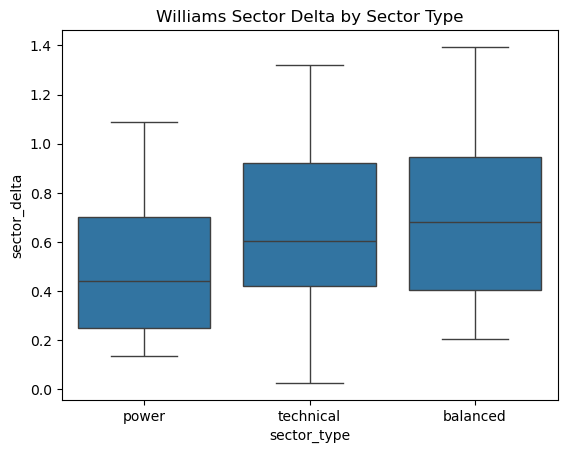

In [41]:
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import zscore 

# z-score check (over +3 or under -3)
df_labelled_sectors['zscore'] = zscore(df_labelled_sectors['sector_delta'])

print("\nZ-score check for outliers - results:\n")
print(df_labelled_sectors[df_labelled_sectors['zscore'].abs() > 3])

# create a boxplot to spot outliers visually
sns.boxplot(
	x = 'sector_type', 
	y = 'sector_delta', 
	data = df_labelled_sectors
)
plt.title("Williams Sector Delta by Sector Type")
plt.show()

- An empty DataFrame from z-score check confirms no outlier values (using |zscore| > 3 test)
- `is_accurate == True`, non-deleted laps and manual session curation yielded a dataset free of extreme values.
- No evidence of values that could distort summary statistics or bias hypothesis testing. 
- Results reflect genuine and representative Williams versus midfield gaps.

## Step 8: Export final labelled sectors DataFrame to CSV

In [42]:
df_labelled_sectors.to_csv("../processed_data/williams-deltas-by-sector-type.csv")